# Множественное тестирование гипотез

In [ ]:
import warnings
warnings.filterwarnings("ignore")

try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    !wget -q -O requirements.txt https://raw.githubusercontent.com/Intelligent-Systems-Phystech/psad/master/seminars/sem4/requirements.txt
    !pip install -q -r requirements.txt

## Библиотеки

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

import scipy.stats as st
import seaborn as sns

# критерий стюдента для независимых выборок
from  statsmodels.stats.weightstats import ttest_ind

# пакет для работы с множественным тестированием
from statsmodels.stats.multitest import multipletests

# пакет для проверки множественных гипотез
from statsmodels.stats.multitest import multipletests

## Warmup

### Модельный эксперимент

#### Постановка
**Данные:**

$n=20, \quad m=200, \quad m_0=150$,

$\mathbf{X}_i \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \quad i=1,\dots,m_0;$

$\mathbf{X}_i \sim \mathcal{N}(\mathbf{1}, \mathbf{I}), \quad i=m_0+1,\dots,m;$

$\mathbf{X}_i \in \mathbb{R}^n.$

**Гипотезы:**

$H^i_0: \mathsf{E}\mathbf{X}_i = 0$;

$H^i_1: \mathsf{E}\mathbf{X}_i \neq 0$;


**Критерий для проверки:**
* одновыборочный t-Критерия Стьюдента.

#### Генерация данных

In [3]:
rs = np.random.RandomState(42)

alpha = 0.05
m = 200
m0 = 150
n = 20

X = rs.randn(m,n)
X[m0:]+=1

#### Гистограммы

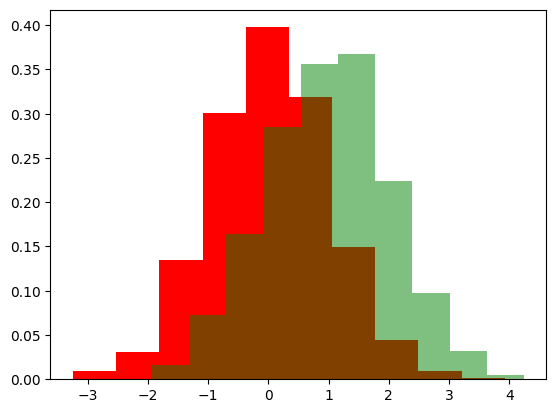

In [4]:
_ = plt.hist(X[:m0].flatten(), color='r', density=True)
_ = plt.hist(X[m0:].flatten(), color='g', alpha=0.5, density=True)

#### Эксперимент

В качестве статистики использовать функцию ```st.ttest_1samp``` из пакета ```scipy.stats```.

##### Без поправок

In [5]:
# zero mean
rejected = 0
for x in X[:m0]:
    if st.ttest_1samp(x, 0, )[1] < 0.05:
         rejected += 1

print ('True: H0; H1 non-accepted:', m0 - rejected)
print ('True: H0; H0 rejected:', rejected)

# non-zero mean
rejected = 0
for x in X[m0:]:
    if st.ttest_1samp(x, 0)[1] < 0.05:
         rejected += 1

print ('False: H1; H1 non-accepted:', m-m0 - rejected)
print ('False: H1; H0 rejected:', rejected)

True: H0; H1 non-accepted: 139
True: H0; H0 rejected: 11
False: H1; H1 non-accepted: 0
False: H1; H0 rejected: 50


##### Бонферони (из пакета)

In [6]:
# zero mean
p_values = []
for x in X:
    p_values.append(st.ttest_1samp(x, 0, )[1])

rejections = multipletests(p_values, method='bonferroni')[0]

print ('True: H0; H1 non-accepted:', m0 - rejections[:m0].sum())
print ('True: H0; H1 rejected:',  rejections[:m0].sum())

# non-zero mean
rejections = multipletests(p_values, method='bonferroni')[0]

print ('True: H1;  H1 non-accepted:', m-m0 - rejections[m0:].sum())
print ('True: H1;  H1 rejected:',  rejections[m0:].sum())



True: H0; H1 non-accepted: 150
True: H0; H1 rejected: 0
True: H1;  H1 non-accepted: 30
True: H1;  H1 rejected: 20


##### Бонферони (руками)

In [7]:
# zero mean
rejected = 0
for x in X[:m0]:
    if st.ttest_1samp(x, 0, )[1] < 0.05/200:
         rejected += 1

print ('True: H0; H1 non-accepted:', m0 - rejected)
print ('True: H0; H0 rejected:', rejected)

# non-zero mean
rejected = 0
for x in X[m0:]:
    if st.ttest_1samp(x, 0, )[1] < 0.05/200:
         rejected += 1

print ('True: H1; H1 non-accepted:', m-m0 - rejected)
print ('True: H1; H0 rejected:', rejected)

True: H0; H1 non-accepted: 150
True: H0; H0 rejected: 0
True: H1; H1 non-accepted: 30
True: H1; H0 rejected: 20


##### График зависимости мощности для разных поправок

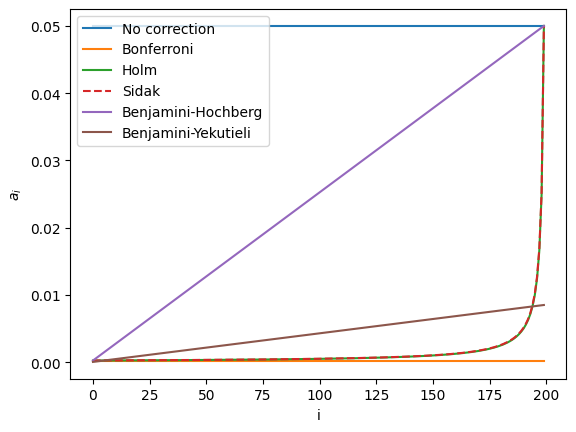

In [8]:
# no correction
plt.plot([0, m - 1], [alpha] * 2, label='No correction')

# bonferroni
bonferroni = alpha / m
plt.plot([0, m - 1], [bonferroni] * 2, label='Bonferroni')

# holm
holm = alpha / np.arange(m, 0, -1)
plt.plot(holm, label='Holm')

# sidak
sidak = 1 - np.power((1. - alpha),  1. / np.arange(m, 0, -1))
plt.plot(sidak, label='Sidak', ls='--')

# benjamini-hochberg
ecdffactor = np.arange(1, m + 1)/float(m)
bh = alpha * ecdffactor
plt.plot(range(m), bh, label='Benjamini-Hochberg')

# benjamini-yekutieli
cm = np.sum(1. / np.arange(1, m+1))
ecdffactor = ecdffactor / cm
by = alpha * ecdffactor
plt.plot(range(m), by, label='Benjamini-Yekutieli')

plt.xlabel('i')
plt.ylabel('$a_i$')
plt.legend(loc='best')

plt.show()

##### График модифицированых уровней значимости

In [9]:
def plot_diff_alpha(p_values, loc_plt=None):
    '''
    Функция для отрисовки модифицированых, отсортированых
    уровней значимости для модельной выборки.

    param: p_values --- список уровней значимости
    param: loc_plt --- объект matplotlib.pylab где производится отрисовка

    return: loc_plt --- объект matplotlib.pylab после отрисовки
    '''
    if loc_plt is None:
        return None
    argsorted_p = np.argsort(p_values)
    false = []
    true = []
    for i, id in enumerate(argsorted_p):
        if id>m0:
            false.append((i, p_values[id]))
        else:
            true.append((i, p_values[id]))

    loc_plt.scatter(*zip(*true), label='True hypothesis', c='b')
    loc_plt.scatter(*zip(*false), label='False hypothesis', c='r')
    loc_plt.xlabel('sorted i')
    loc_plt.ylabel('$\hat{p}(i)$')
    loc_plt.legend(loc='best')

    return loc_plt

##### График модифицированых уровней значимости (без поправок)

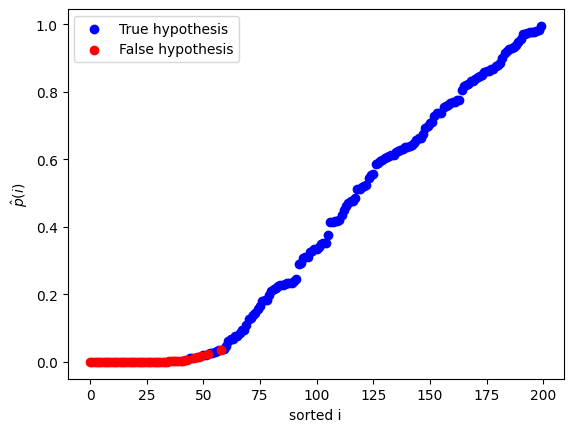

In [10]:
p_values = []
for x in X:
     p_values.append(st.ttest_1samp(x, 0)[1])

plot_diff_alpha(p_values, loc_plt=plt)
plt.show()

##### График модифицированых уровней значимости (Bonferroni)

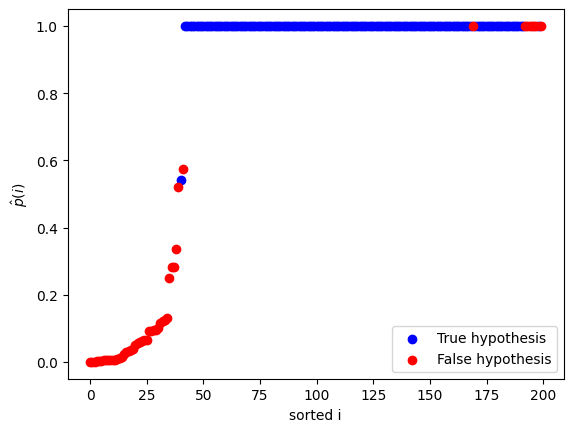

In [11]:
p_values = []
for x in X:
     p_values.append(st.ttest_1samp(x, 0)[1])

p_values = multipletests(p_values, method='bonferroni')[1]

plot_diff_alpha(p_values, loc_plt=plt)
plt.show()

##### График модифицированых уровней значимости (Holm)

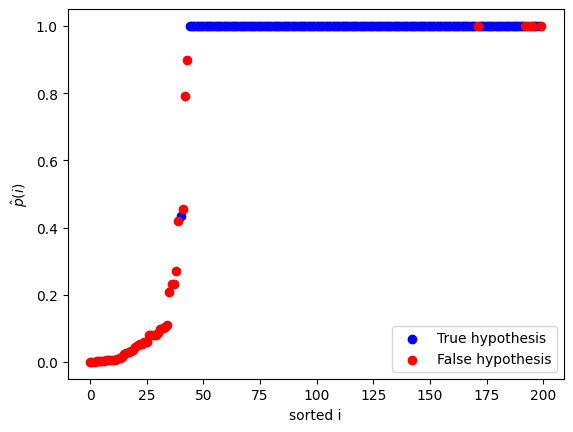

In [12]:
p_values = []
for x in X:
     p_values.append(st.ttest_1samp(x, 0)[1])

p_values = multipletests(p_values, method='holm')[1]

plot_diff_alpha(p_values, loc_plt=plt)
plt.show()

##### График модифицированых уровней значимости (Holm-Sidak)

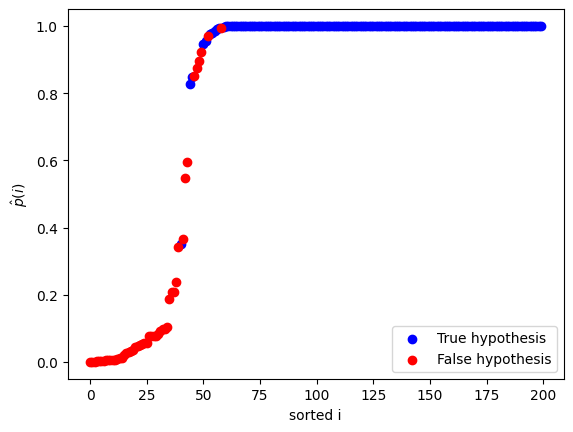

In [13]:
p_values = []
for x in X:
     p_values.append(st.ttest_1samp(x, 0)[1])

p_values = multipletests(p_values, method='holm-sidak')[1]

plot_diff_alpha(p_values, loc_plt=plt)
plt.show()

##### График модифицированых уровней значимости (Benjamini-Hochberg)

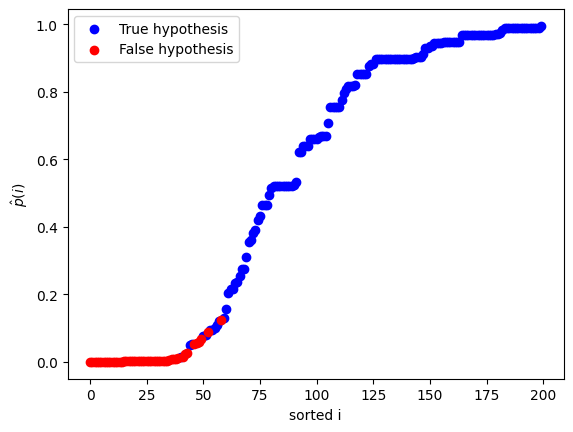

In [14]:
p_values = []
for x in X:
     p_values.append(st.ttest_1samp(x, 0)[1])

p_values = multipletests(p_values, method='fdr_bh', )[1]

plot_diff_alpha(p_values, loc_plt=plt)
plt.show()

##### График модифицированых уровней значимости (Benjamini-Yekutieli)

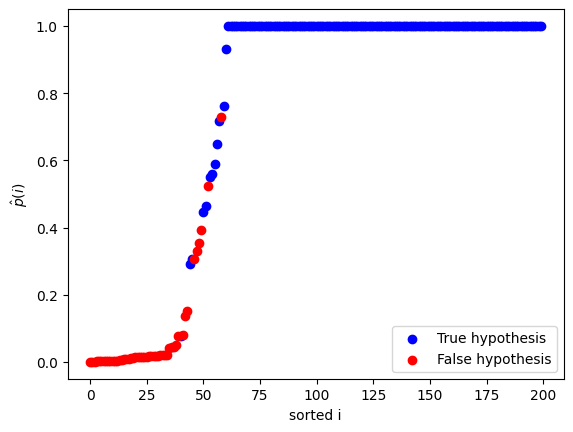

In [15]:
p_values = []
for x in X:
     p_values.append(st.ttest_1samp(x, 0)[1])

p_values = multipletests(p_values, method='fdr_by', )[1]

plot_diff_alpha(p_values, loc_plt=plt)
plt.show()

## Лейкоциты и астма

С использованием ДНК-микрочипов были получены анализ изменения генной экспрессии для двух групп детей: больных астмой и здоровых.

Источник данных: http://www.ncbi.nlm.nih.gov/sites/GDSbrowser?acc=GDS4896

### Рассмотрим сами данные

In [16]:
data = pd.read_csv('https://raw.githubusercontent.com/Intelligent-Systems-Phystech/psad/master/seminars/sem4/data/expression.csv', delimiter=';')

In [17]:
data.head(5)

,ID_REF,IDENTIFIER,Healthy control,Healthy control.1,Healthy control.2,Healthy control.3,Healthy control.4,Healthy control.5,Healthy control.6,Healthy control.7,...,Severe asthma.8,Severe asthma.9,Severe asthma.10,Severe asthma.11,Severe asthma.12,Severe asthma.13,Severe asthma.14,Severe asthma.15,Severe asthma.16,Gene title
0,7933640,A1CF,4.24505,4.44464,4.36671,4.33497,4.45717,4.37972,4.40154,4.40521,...,4.59426,4.56012,4.60672,4.43026,4.55835,4.25656,4.52559,4.42976,4.37098,APOBEC1 complementation factor
1,7960947,A2M,4.79868,4.76833,4.66414,4.80272,4.85779,4.77622,4.92634,4.88576,...,5.01994,5.15406,5.13639,4.99052,4.88454,4.68904,4.85329,5.05764,5.48561,alpha-2-macroglobulin
2,7953775,A2ML1,4.79161,5.12633,4.93860,4.74597,4.91789,4.74453,5.23725,4.83903,...,5.22915,5.11131,5.33257,5.05544,4.96971,4.96505,4.76993,5.04489,4.70002,alpha-2-macroglobulin-like 1
3,8076497,A4GALT,5.79783,5.93942,5.82935,5.91139,5.60195,5.68317,6.01254,5.84921,...,6.16251,6.21829,6.06835,5.80154,6.06533,5.79955,5.94065,6.08192,5.86693,"alpha 1,4-galactosyltransferase"
4,8090955,A4GNT,3.79685,4.00154,3.83103,3.91021,3.81930,3.86203,3.97020,3.84166,...,4.17925,3.99698,4.09657,4.00232,3.70843,3.79290,4.31364,3.94925,3.62481,"alpha-1,4-N-acetylglucosaminyltransferase"


In [18]:
len(data)

28231

In [19]:
print('\n'.join(list(data.columns)))

ID_REF
IDENTIFIER
Healthy control
Healthy control.1
Healthy control.2
Healthy control.3
Healthy control.4
Healthy control.5
Healthy control.6
Healthy control.7
Healthy control.8
Healthy control.9
Healthy control.10
Healthy control.11
Healthy control.12
Healthy control.13
Healthy control.14
Healthy control.15
Healthy control.16
Healthy control.17
Mild asthma
Mild asthma.1
Mild asthma.2
Mild asthma.3
Mild asthma.4
Mild asthma.5
Mild asthma.6
Mild asthma.7
Mild asthma.8
Mild asthma.9
Mild asthma.10
Mild asthma.11
Mild asthma.12
Mild asthma.13
Mild asthma.14
Mild asthma.15
Mild asthma.16
Mild asthma.17
Mild asthma.18
Severe asthma
Severe asthma.1
Severe asthma.2
Severe asthma.3
Severe asthma.4
Severe asthma.5
Severe asthma.6
Severe asthma.7
Severe asthma.8
Severe asthma.9
Severe asthma.10
Severe asthma.11
Severe asthma.12
Severe asthma.13
Severe asthma.14
Severe asthma.15
Severe asthma.16
Gene title


### Эксперимент

#### Достигаемые уровни значимости в t-Критерии Стьюдента

In [20]:
data_np = data.values
def get_healthy(i):
    '''
    Возвращает всех здоровых пациентов для i-го микрочипа
    '''
    return data_np[i, 2:20]

def get_asthma(i):
    '''
    Возвращает всех больных астмой пациентов для i-го микрочипа
    '''
    return data_np[i, 39:56]

def get_pvalue_t_test(i):
    '''
    Возвращает p-value для критерия Стьюдента для независимых выборок
    '''
    return ttest_ind(get_healthy(i), get_asthma(i), usevar='unequal')[1]

p_values = list(map(get_pvalue_t_test, range(data_np.shape[0])))
p_values = np.array(p_values)

#### Модифицированые уровни значимости

In [21]:
p_holm = multipletests(p_values, method='holm')[1]

p_bh = multipletests(p_values, method='fdr_bh', )[1]

In [22]:
p_values

array([0.23998039, 0.00125341, 0.88390126, ..., 0.15137804, 0.3311369 ,
       0.64441411])

#### Распределения исходных и модифицированных достигаемых уровней значимости

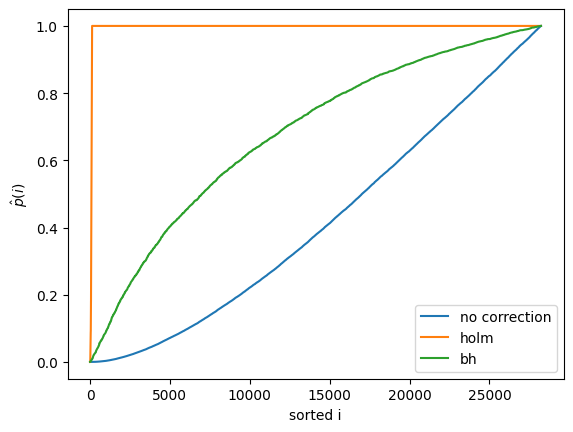

In [23]:
plt.plot(sorted(p_values), label='no correction')

plt.plot(sorted(p_holm), label='holm')

plt.plot(sorted(p_bh), label='bh')

plt.xlabel('sorted i')
plt.ylabel('$\hat{p}(i)$')
plt.legend(loc='best')
plt.show()

#### Количество генов, экспрессия которых статистически значимо отличается при поправке методами Холма и Бенджамини-Хохберга:

In [24]:
print('Количество генов для которых значимо отличается: {}\t(no correction)'.format((p_values <= 0.05).sum()))
print('Количество генов для которых значимо отличается: {}\t(holm)'.format((p_holm <= 0.05).sum()))
print('Количество генов для которых значимо отличается: {}\t(bh)'.format((p_bh <= 0.05).sum()))

Количество генов для которых значимо отличается: 4087	(no correction)
Количество генов для которых значимо отличается: 31	(holm)
Количество генов для которых значимо отличается: 564	(bh)


### На микрочипах есть много проб к малоизученным участкам генома, у которых даже нет названия; их можно сразу удалить из рассмотрения (Эксперимент 2)

In [25]:
reduced_data = data[data['Gene title'].isnull() == False]
reduced_data.shape, data.shape

((21465, 57), (28231, 57))

#### Рассмотрим как изменились уровни значимости

In [26]:
data_np = reduced_data.values

p_values = list(map(get_pvalue_t_test, range(data_np.shape[0])))
p_values = np.array(p_values)

In [27]:
p_holm = multipletests(p_values, method='holm')[1]

p_bh = multipletests(p_values, method='fdr_bh')[1]

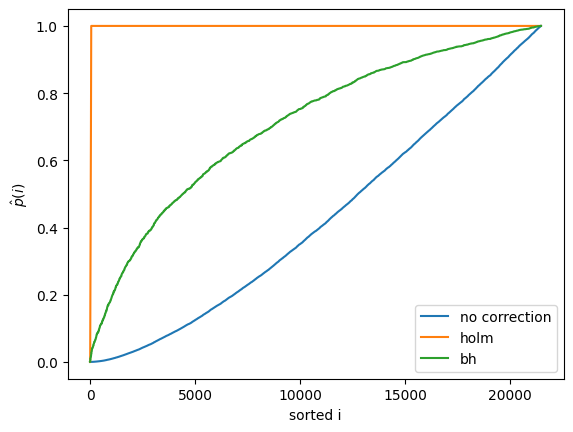

In [28]:
plt.plot(sorted(p_values), label='no correction')

plt.plot(sorted(p_holm), label='holm')

plt.plot(sorted(p_bh), label='bh')

plt.xlabel('sorted i')
plt.ylabel('$\hat{p}(i)$')
plt.legend(loc='best')
plt.show()

In [29]:
print('Количество генов для которых значимо отличается: {}\t(no correction)'.format((p_values <= 0.05).sum()))
print('Количество генов для которых значимо отличается: {}\t(holm)'.format((p_holm <= 0.05).sum()))
print('Количество генов для которых значимо отличается: {}\t(bh)'.format((p_bh <= 0.05).sum()))

Количество генов для которых значимо отличается: 2772	(no correction)
Количество генов для которых значимо отличается: 9	(holm)
Количество генов для которых значимо отличается: 168	(bh)


## Сравнение качества классификаторов

Дано: AUC различных версий алгоритма C4.5, посчитанный на 15 датасетах.

**Demsar J. (2006). Statistical Comparisons of Classifiers over Multiple Data Sets. Journal of Machine Learning Research, 7, 1–30.**

### Рассмотрим данные

In [30]:
data = pd.read_csv('https://raw.githubusercontent.com/Intelligent-Systems-Phystech/psad/master/seminars/sem4/data/auc.txt', delimiter='\t')

In [31]:
data.head(5)

,Dataset,C4.5,C4.5+m,C4.5+cf,C4.5+m+cf
0,adult (sample),0.763,0.768,0.771,0.798
1,breast cancer,0.599,0.591,0.590,0.569
2,breast cancer wisconsin,0.954,0.971,0.968,0.967
3,cmc,0.628,0.661,0.654,0.657
4,ionosphere,0.882,0.888,0.886,0.898


### Эксперимент

Между какими из версий есть значимые различия?

Сравним все значения критерия качества попарно с помощью критерия знаковых рангов Уилкоксона (```st.wilcoxon```):

In [32]:
p_values= []
for i in range(1, 5):
    for j in range(i+1, 5):
        test_result = st.wilcoxon(data.iloc[:, i].values, data.iloc[:, j].values) ### Ваш код тут ###
        p_values += [test_result[1]]
        print(data.columns[i], data.columns[j], p_values[-1])

C4.5 C4.5+m 0.01075713311978963
C4.5 C4.5+cf 0.861262330095348
C4.5 C4.5+m+cf 0.015874359307532084
C4.5+m C4.5+cf 0.05432871367198416
C4.5+m C4.5+m+cf 0.3278256758446406
C4.5+cf C4.5+m+cf 0.025313519968766574


### Разные поправки

In [33]:
for k in ['bonferroni', 'holm', 'fdr_bh', 'fdr_by']:
    rejects, p_val, *_ = multipletests(p_values, method=k)

    print(f'{k}\n{str(rejects)}\n{str(p_val)}\n\n')

bonferroni
[False False False False False False]
[0.0645428  1.         0.09524616 0.32597228 1.         0.15188112]


holm
[False False False False False False]
[0.0645428  0.86126233 0.0793718  0.16298614 0.65565135 0.10125408]


fdr_bh
[ True False  True False False False]
[0.04762308 0.86126233 0.04762308 0.08149307 0.39339081 0.05062704]


fdr_by
[False False False False False False]
[0.11667654 1.         0.11667654 0.19965802 0.96380749 0.12403625]


